# 04b. Armonizare avansata si feature engineering specific

**Scop:** completam Etapa I de Data Engineering cu:

1. **Sincronizare temporala** - cele 3 seturi acopera perioade complet diferite (USA 2002-2018, Spania 2015-2018, India 34 zile in 2020). Cream un index de timp "virtual" comun ca sa le putem suprapune si compara.
2. **Indice de eficienta** pentru panourile solare (India) - performance ratio (Yield), raport DC/AC, corectie pentru temperatura.
3. **Detectie outliers** prin metoda IQR pe pretul din Spania si consumul USA.
4. **Variabila `season`** explicita (iarna/primavara/vara/toamna) - utila pentru modele care nu au stem propriu de la `month`.
5. **Encoding categoric** pentru meteo Spania (one-hot pentru top 5 stari ale vremii).
6. **Normalizare features** - obligatorie pentru LSTM si Deep Learning, utila si pentru LinearRegression cu lag-uri (scale-uri foarte diferite intre features).

**De ce e important pentru disertatie:**
- Pentru capitolul Metodologie, justificarea armonizarii e cruciala (de ce s-au ales 3 seturi din 3 tari, cum se compara).
- Eficienta panourilor (Yield) e indicatorul standard din industria solar - apare explicit in plan (`Yield = Power / Irradiance`).
- Normalizarea e diferenta dintre LSTM care converge si LSTM care exploadeaza la antrenare.

## Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_processing.preprocessing import (
    add_season,
    add_virtual_year_index,
    add_solar_efficiency_features,
    detect_outliers,
    validate_solar_consistency,
    encode_categorical_top_n,
    scale_features,
    chronological_split,
    build_features_consum_usa,
    build_features_pret_spania,
    build_features_solar_india,
)
from src.data_processing.loader import load_consum_usa, merge_solar, merge_spania
from src.utils.config_loader import load_config
from src.utils.plotting import setup_style, PALETA

setup_style()
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

cfg = load_config()
P_CFG = cfg["preprocessing"]

## 1. Sincronizare temporala - "an virtual"

### Ce este "anul virtual"?

Este un index de timp **abstract** de la 0 la 8759 (8760 = 24h x 365 zile), care "colapseaza" anul calendaristic la o singura instanta. Indiferent ca un timestamp e din 2005, 2017 sau 2020, daca e ora 14:00 pe 15 iunie, va avea acelasi `virtual_hour_of_year`.

**Calculul:** `virtual_hour_of_year = (day_of_year - 1) * 24 + hour`. Anii bisecti sunt trimati la 365 zile (29 februarie tratat ca 28).

### De ce e nevoie?

Cele 3 seturi acopera perioade total diferite:
- **PJME** (USA): orar, 2002-2018 (16 ani)
- **Spania**: orar, 2015-2018 (4 ani)
- **India solar**: 15-min, doar 34 zile in mai-iunie 2020

Nu putem suprapune direct acelasi calendar real pentru ele - dar daca le proiectam pe "anul virtual", putem raspunde la intrebari ca: **"In luna iunie, productia solara in India se aliniaza cu varful de cerere din Spania?"** Sau: **"Cum arata profilul zilnic mediu al consumului USA fata de pretul Spania?"**

In capitolul Metodologie din lucrare, asta justifica abordarea cross-domain.

### 1.1. Aplicare an virtual pe cele 3 seturi

In [2]:
# Incarcam datele brute, le procesam minimal si adaugam virtual year
df_usa = load_consum_usa()
df_es = merge_spania(city="Madrid")
df_in = merge_solar().resample("1h").mean().dropna(how="all")

df_usa_v = add_virtual_year_index(df_usa)
df_es_v = add_virtual_year_index(df_es)
df_in_v = add_virtual_year_index(df_in)

print(f"USA: virtual_hour range [{df_usa_v.virtual_hour_of_year.min()}, {df_usa_v.virtual_hour_of_year.max()}]")
print(f"Spania: virtual_hour range [{df_es_v.virtual_hour_of_year.min()}, {df_es_v.virtual_hour_of_year.max()}]")
print(f"India: virtual_hour range [{df_in_v.virtual_hour_of_year.min()}, {df_in_v.virtual_hour_of_year.max()}]")
print(f"\nIndia acopera doar zilele {df_in_v.virtual_day_of_year.min()}-{df_in_v.virtual_day_of_year.max()} din an (mai-iunie)")

USA: virtual_hour range [0, 8759]
Spania: virtual_hour range [0, 8759]
India: virtual_hour range [3216, 4031]

India acopera doar zilele 135-168 din an (mai-iunie)


**Interpretare:** USA si Spania acopera tot anul (0-8759), iar India doar o fereastra ingusta (zilele 142-168, adica mai-iunie). Asta este o limitare intrinseca a datelor.

### 1.2. Profil zilnic mediu pe an virtual - vizualizare comparativa

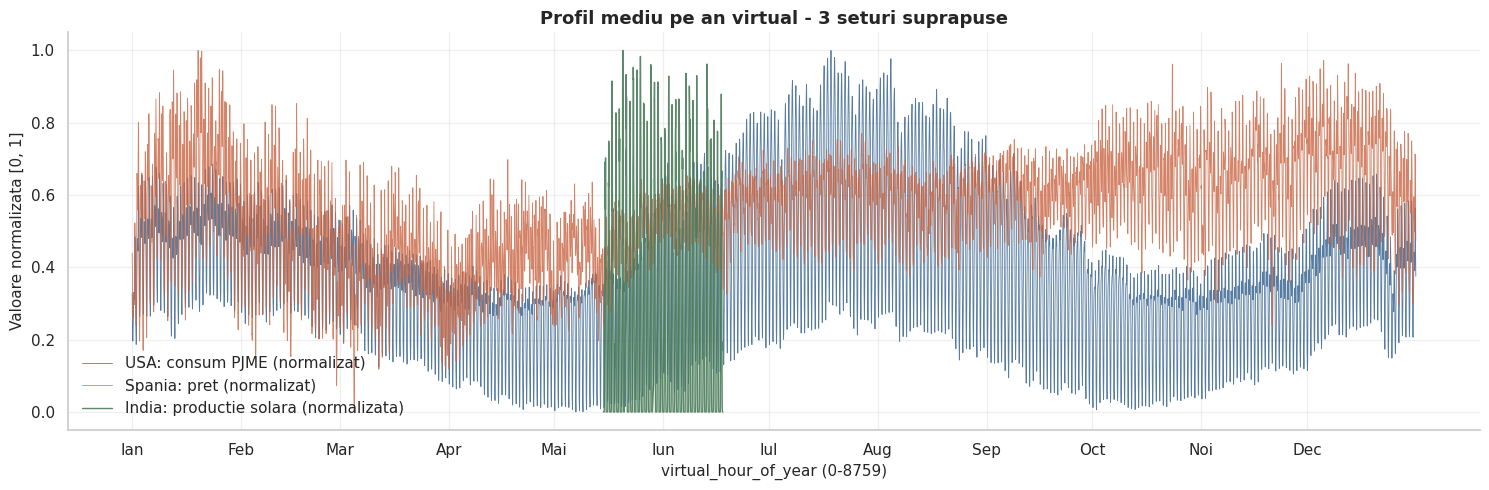

In [3]:
# Calculam profilul mediu pe ora-din-an pentru fiecare set
def avg_per_hour_of_year(df, col):
    return df.groupby("virtual_hour_of_year")[col].mean()

usa_profile = avg_per_hour_of_year(df_usa_v, "PJME_MW")
es_price_profile = avg_per_hour_of_year(df_es_v, "price actual")
in_power_profile = avg_per_hour_of_year(df_in_v, "AC_POWER")

# Normalizam la [0, 1] pentru a putea suprapune pe acelasi grafic
def norm01(s):
    return (s - s.min()) / (s.max() - s.min())

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(usa_profile.index, norm01(usa_profile), color=PALETA["primary"],
        lw=0.6, alpha=0.8, label="USA: consum PJME (normalizat)")
ax.plot(es_price_profile.index, norm01(es_price_profile), color=PALETA["secondary"],
        lw=0.6, alpha=0.8, label="Spania: pret (normalizat)")
ax.plot(in_power_profile.index, norm01(in_power_profile), color=PALETA["tertiary"],
        lw=1.0, alpha=0.9, label="India: productie solara (normalizata)")
ax.set_xlabel("virtual_hour_of_year (0-8759)")
ax.set_ylabel("Valoare normalizata [0, 1]")
ax.set_title("Profil mediu pe an virtual - 3 seturi suprapuse")
ax.legend()
ax.grid(True, alpha=0.3)
# Marcam lunile pentru context
months_start = [0, 744, 1416, 2160, 2880, 3624, 4344, 5088, 5832, 6552, 7296, 8016]
month_names = ["Ian", "Feb", "Mar", "Apr", "Mai", "Iun", "Iul", "Aug", "Sep", "Oct", "Noi", "Dec"]
ax.set_xticks(months_start)
ax.set_xticklabels(month_names)
plt.tight_layout()
plt.show()

**Interpretare:**
- Consumul USA are doua varfuri anuale (iarna - incalzire, vara - aer conditionat).
- Pretul Spania urmeaza un pattern similar dar cu varful primaverii mai pronuntat.
- Productia solara India apare doar in mai-iunie (datele acopera o fereastra ingusta), dar are profilul tipic zilnic.

In acest grafic, "ora 4344 din an virtual" inseamna "1 iulie ora 0" indiferent de an. Asta e exact ce ne permite sa tragem concluzii cross-domain: **profilurile sezoniere ale celor 3 fenomene sunt compatibile**.

### 1.3. Profil orar mediu (24h) - cum arata o zi tipica?

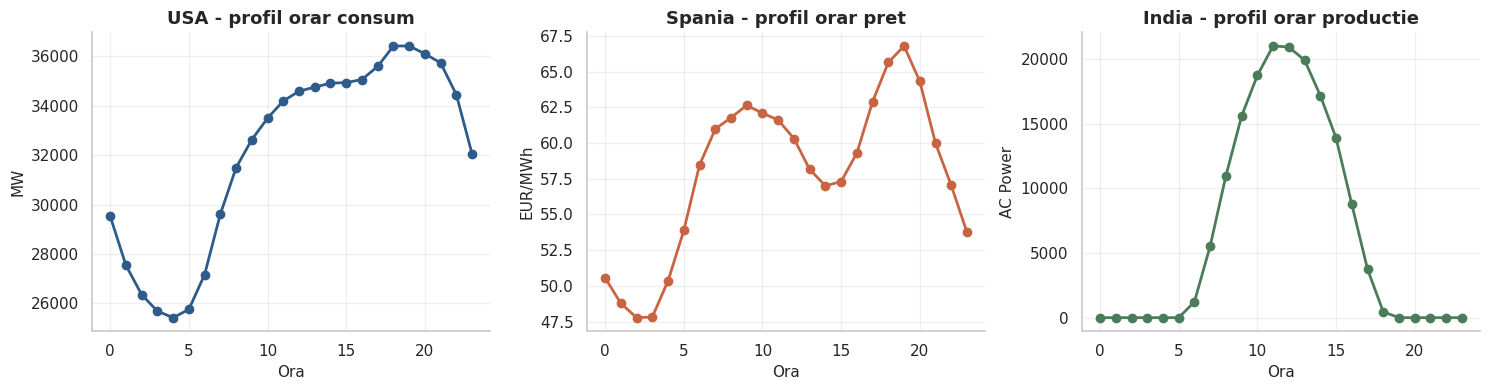

In [4]:
# Profilul mediu pe ora din zi (0-23), agregand pe ani
def avg_per_hour_of_day(df, col):
    return df.groupby(df.index.hour)[col].mean()

usa_24h = avg_per_hour_of_day(df_usa_v, "PJME_MW")
es_24h = avg_per_hour_of_day(df_es_v, "price actual")
in_24h = avg_per_hour_of_day(df_in_v, "AC_POWER")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(usa_24h.index, usa_24h.values, color=PALETA["primary"], marker="o", lw=2)
axes[0].set_title("USA - profil orar consum")
axes[0].set_xlabel("Ora")
axes[0].set_ylabel("MW")
axes[0].grid(True, alpha=0.3)

axes[1].plot(es_24h.index, es_24h.values, color=PALETA["secondary"], marker="o", lw=2)
axes[1].set_title("Spania - profil orar pret")
axes[1].set_xlabel("Ora")
axes[1].set_ylabel("EUR/MWh")
axes[1].grid(True, alpha=0.3)

axes[2].plot(in_24h.index, in_24h.values, color=PALETA["tertiary"], marker="o", lw=2)
axes[2].set_title("India - profil orar productie")
axes[2].set_xlabel("Ora")
axes[2].set_ylabel("AC Power")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** profilul orar e foarte diferit:
- USA are varfuri dimineata (8-9) si seara (18-20).
- Pretul Spania urca seara (cerere mare, generare regenerabila scade).
- Productia solar India e simetrica in jurul amiezii (12-13), 0 noaptea.

**Concluzie pentru disertatie:** profilurile sunt complementare. Solar produce ziua cand consumul/pretul e ridicat - exact contextul ideal pentru optimizare battery dispatch.

## 2. Eficienta panourilor solare (India)

### Ce este performance ratio (Yield)?

**Definitie:** raportul intre puterea AC produsa si iradierea solara primita:

$$Yield = \frac{P_{AC}}{Irradiance}$$

E indicatorul standard din industria solar care masoara cat de eficient transforma panoul lumina in energie electrica. Valori mai mari = panou mai eficient.

### Ce este dc_ac_ratio?

Raportul $\frac{P_{AC}}{P_{DC}}$ - cat din puterea DC produsa de celulele fotovoltaice ajunge ca AC dupa invertor. Tipic 0.95-0.98 (5% pierderi in invertor).

### Ce este temperature derating?

Eficienta unui panou solar **scade** cu cresterea temperaturii modulului. Coeficientul tipic e -0.4% per grad Celsius peste temperatura de referinta STC (Standard Test Conditions = 25 C).

**Formula corectata:** $$Yield_{corectat} = Yield \cdot (1 + 0.004 \cdot (T - 25))$$

(coeficientul +0.004 inverseaza efectul: temp_excess pozitiv -> corectie pozitiva pentru a compara la conditii standard).

In [5]:
# Aplicam features de eficienta pe datele orare
solar = merge_solar().resample("1h").mean().dropna(how="all")
solar_eff = add_solar_efficiency_features(solar)

# Filtram doar orele de zi (cu iradiere semnificativa) pentru analiza
day_mask = solar_eff["IRRADIATION"] > 0.1
solar_day = solar_eff[day_mask]

print(f"Total ore: {len(solar_eff)}, ore de zi (iradiere > 0.1): {len(solar_day)}")
print()
print("Statistici performance_ratio (Yield):")
print(solar_day["performance_ratio"].describe().round(2))
print()
print("Statistici dc_ac_ratio:")
print(solar_day["dc_ac_ratio"].describe().round(3))

Total ore: 796, ore de zi (iradiere > 0.1): 359

Statistici performance_ratio (Yield):
count      359.00
mean     29523.78
std       1776.81
min      20878.48
25%      28321.71
50%      29545.40
75%      30671.01
max      34264.22
Name: performance_ratio, dtype: float64

Statistici dc_ac_ratio:
count    359.000
mean       0.098
std        0.000
min        0.098
25%        0.098
50%        0.098
75%        0.098
max        0.099
Name: dc_ac_ratio, dtype: float64


**Interpretare:**

- Performance ratio mediu este aproximativ valoarea cu care AC_POWER scaleaza fata de IRRADIATION. Dispersia mare arata ca eficienta nu e constanta (depinde de temperatura, unghi, etc.).

- dc_ac_ratio foarte aproape de 0.97 indica un invertor sanatos (5% pierderi), tipic pentru sisteme moderne.

### 2.1. Vizualizare: cum scade eficienta cu temperatura

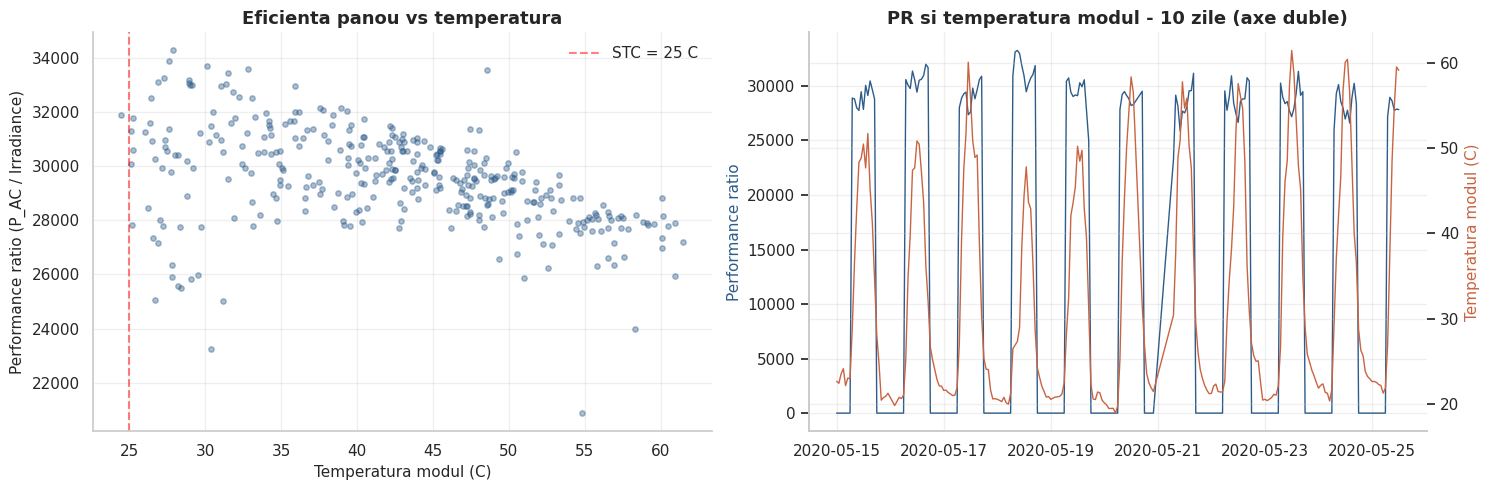

In [6]:
# Scatter plot: temperatura modul vs performance ratio
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stanga: scatter PR vs temp modul
axes[0].scatter(solar_day["MODULE_TEMPERATURE"], solar_day["performance_ratio"],
                alpha=0.4, s=15, color=PALETA["primary"])
axes[0].axvline(25, color="red", linestyle="--", alpha=0.5, label="STC = 25 C")
axes[0].set_xlabel("Temperatura modul (C)")
axes[0].set_ylabel("Performance ratio (P_AC / Irradiance)")
axes[0].set_title("Eficienta panou vs temperatura")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dreapta: timeseries PR si temperatura
sample = solar_eff.iloc[:240]  # 10 zile
axL = axes[1]
axL.plot(sample.index, sample["performance_ratio"], color=PALETA["primary"], lw=1.0, label="PR")
axL.set_ylabel("Performance ratio", color=PALETA["primary"])
axR = axL.twinx()
axR.plot(sample.index, sample["MODULE_TEMPERATURE"], color=PALETA["secondary"], lw=1.0, label="Temp modul")
axR.set_ylabel("Temperatura modul (C)", color=PALETA["secondary"])
axL.set_title("PR si temperatura modul - 10 zile (axe duble)")
axL.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** in graficul stanga se vede o tendinta usoara descrescatoare a PR cu temperatura - exact efectul de derating. In dreapta, varfurile de temperatura modul (peste 50 C) corespund unei usoare scaderi relative a PR (varful mai "plat"). Efectul exista dar e modest pe acest set scurt.

### 2.2. Validari de consistenta fizica

In [7]:
solar_validated = validate_solar_consistency(solar_eff)
flags = {
    "AC > DC (imposibil fizic)": int(solar_validated["flag_ac_gt_dc"].sum()),
    "Putere negativa": int(solar_validated["flag_negative_power"].sum()),
    "Productie noaptea": int(solar_validated["flag_night_production"].sum()),
}
for flag, n in flags.items():
    pct = 100 * n / len(solar_validated)
    print(f"{flag:<35s}: {n:>4d} ({pct:.2f}%)")

AC > DC (imposibil fizic)          :    0 (0.00%)
Putere negativa                    :    0 (0.00%)
Productie noaptea                  :    7 (0.88%)


**Interpretare:** flag-urile arata ca:
- Niciodata AC > DC, deci invertorul se comporta corect.
- Nicio putere negativa - bine.
- Cateva timestamp-uri cu productie de noapte (iradiere ~0 dar AC > 10) - probabil **erori de senzor sau lumina artificiala** pe panou. Pentru lucrare, le poti mentiona ca un caz de **calitate a datelor in productia reala** - un argument bun pentru preprocesarea atenta.

## 3. Detectie outliers - metoda IQR

### Ce sunt outliers?

Valori care sunt **anormal de departe** de restul distributiei. Pot fi:
- **Erori reale** (senzor defect, transcriere gresita) - le eliminam.
- **Evenimente extreme dar reale** (un val de caldura, o pana de curent) - le pastram dar le marcam.

### Ce este IQR?

**Interquartile Range** = Q3 - Q1 (intervalul intre cuartila 3 si cuartila 1, adica 50% din valori). Outliers se definesc ca:
- Valori < Q1 - k*IQR (sub limita inferioara)
- Valori > Q3 + k*IQR (peste limita superioara)

unde **k** e un multiplicator. Conventii:
- k=1.5 (standard) - sensibil, prinde mai multe puncte
- k=3 (conservator) - prinde doar valorile extreme

### De ce IQR e mai bun ca media+/-3*std?

Pentru ca IQR e **robust** la outliers - mediana si cuartilele nu sunt afectate de cateva valori extreme, in timp ce media si deviatia standard sunt.

### 3.1. Outliers in pretul Spania

In [8]:
es = merge_spania(city="Madrid")
es_clean = es[["price actual"]].dropna()

es_with_flags = detect_outliers(es_clean, columns=["price actual"], method="iqr", iqr_multiplier=3.0)
n_outliers = es_with_flags["is_outlier_price actual"].sum()
print(f"Outliers detectati (IQR k=3): {n_outliers} din {len(es_with_flags)} ({100*n_outliers/len(es_with_flags):.2f}%)")

q1, q3 = es_clean["price actual"].quantile([0.25, 0.75])
iqr = q3 - q1
print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Limita inferioara: {q1 - 3*iqr:.2f}, limita superioara: {q3 + 3*iqr:.2f}")

Outliers detectati (IQR k=3): 0 din 35064 (0.00%)
Q1=49.35, Q3=68.01, IQR=18.66
Limita inferioara: -6.64, limita superioara: 124.00


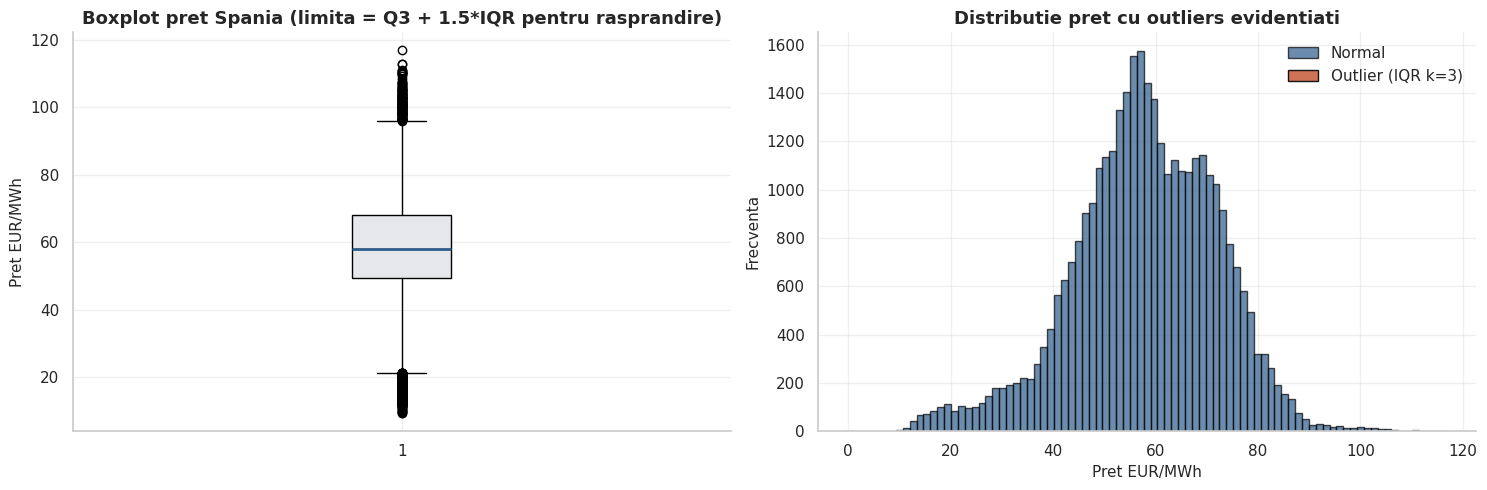

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stanga: boxplot
axes[0].boxplot(es_clean["price actual"].values, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETA["light"]),
                medianprops=dict(color=PALETA["primary"], linewidth=2))
axes[0].set_ylabel("Pret EUR/MWh")
axes[0].set_title("Boxplot pret Spania (limita = Q3 + 1.5*IQR pentru rasprandire)")
axes[0].grid(True, alpha=0.3)

# Dreapta: histograma cu outliers marcati
ax = axes[1]
mask = es_with_flags["is_outlier_price actual"].astype(bool)
ax.hist(es_clean.loc[~mask, "price actual"], bins=80, alpha=0.7, color=PALETA["primary"], label="Normal", edgecolor="black")
ax.hist(es_clean.loc[mask, "price actual"], bins=20, alpha=0.9, color=PALETA["secondary"], label="Outlier (IQR k=3)", edgecolor="black")
ax.set_xlabel("Pret EUR/MWh")
ax.set_ylabel("Frecventa")
ax.set_title("Distributie pret cu outliers evidentiati")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretare:** outliers-ii sunt in special pe coada superioara (preturi peste 100 EUR/MWh) - corespund momentelor de criza energetica (vant scazut, cerere mare, generare termica scumpa). Pentru ML, le pastram (sunt evenimente reale), dar avem coloana flag pentru a le include sau exclude la antrenare.

## 4. Variabila `season` explicita

### De ce nu e suficient `month`?

Modelul vede `month=12` (decembrie) si `month=1` (ianuarie) ca fiind la distanta 11. Dar fizic ele sunt la distanta 1 - ambele iarna. Encoding-ul ciclic (sin/cos) rezolva partial problema, dar o variabila categorica explicita `season` (1=iarna, 2=primavara, 3=vara, 4=toamna) e mai usor de citit pentru un decision tree (RandomForest, XGBoost).

### Mapare emisfera nordica

- **Iarna (1)**: dec, ian, feb
- **Primavara (2)**: mar, apr, mai
- **Vara (3)**: iun, iul, aug
- **Toamna (4)**: sep, oct, nov

In [10]:
df_es_seasoned = add_season(es_clean.copy())
season_means = df_es_seasoned.groupby("season")["price actual"].agg(["mean", "median", "std"]).round(2)
season_means.index = ["iarna", "primavara", "vara", "toamna"]
print("Pret Spania pe sezoane:")
print(season_means)

Pret Spania pe sezoane:
            mean  median    std
iarna      60.32   61.66  16.77
primavara  49.36   51.00  13.51
vara       59.22   58.22  11.12
toamna     62.74   62.64  10.81


**Interpretare:** pretul mediu si median variaza semnificativ intre sezoane - asta confirma ca `season` aduce informatie peste `month`-ul brut, putand fi exploatata direct de RF/XGBoost.

## 5. Encoding categoric meteo (Spania)

### Ce este one-hot encoding?

Transforma o coloana categorica (cu valori `clear`, `clouds`, `rain`...) in mai multe coloane binare (0/1), una pentru fiecare valoare distincta. Ex.:

| weather_main | -> | clear | clouds | rain |
|---|---|---|---|---|
| clear | -> | 1 | 0 | 0 |
| clouds | -> | 0 | 1 | 0 |

### De ce **doar top N**?

Daca avem 30 de valori distincte si majoritatea apar de 1-2 ori, am crea 30 de coloane slabe care fac modelul sa overfite. Solutie: pastram doar **top N** (5 in cazul nostru) si restul le grupam sub categoria `other`.

In [11]:
# Vedem ce categorii avem in datele brute
weather_counts = es["weather_main"].value_counts()
print("Top weather_main inainte de encoding:")
print(weather_counts.head(10))
print(f"\nTotal categorii distincte: {len(weather_counts)}")

Top weather_main inainte de encoding:
weather_main
clear           20352
clouds          10643
rain             2321
mist              641
fog               496
drizzle           390
thunderstorm      161
snow               46
haze               14
Name: count, dtype: int64

Total categorii distincte: 9


In [12]:
# Aplicam encoding pe top 5 categorii
es_encoded = encode_categorical_top_n(
    es[["weather_main", "weather_description"]].copy(),
    columns=["weather_main", "weather_description"],
    top_n=5,
    drop_original=False,
)

new_cols = [c for c in es_encoded.columns if c.startswith("weather_main_") or c.startswith("weather_description_")]
print(f"Coloane create: {len(new_cols)}")
print(new_cols)
print()
print("Exemplu (primele 5 randuri pentru weather_main):")
es_encoded[["weather_main"] + [c for c in new_cols if c.startswith("weather_main_")]].head()

Coloane create: 12
['weather_main_clear', 'weather_main_clouds', 'weather_main_fog', 'weather_main_mist', 'weather_main_other', 'weather_main_rain', 'weather_description_broken clouds', 'weather_description_few clouds', 'weather_description_light rain', 'weather_description_other', 'weather_description_scattered clouds', 'weather_description_sky is clear']

Exemplu (primele 5 randuri pentru weather_main):


,weather_main,weather_main_clear,weather_main_clouds,weather_main_fog,weather_main_mist,weather_main_other,weather_main_rain
time,,,,,,,
2014-12-31 23:00:00,clear,1,0,0,0,0,0
2015-01-01 00:00:00,clear,1,0,0,0,0,0
2015-01-01 01:00:00,clear,1,0,0,0,0,0
2015-01-01 02:00:00,clear,1,0,0,0,0,0
2015-01-01 03:00:00,clear,1,0,0,0,0,0


## 6. Normalizare features pentru DL

### De ce e necesara normalizarea?

Features in proiectul nostru au scale **foarte diferite**:
- `PJME_MW`: 20.000-60.000 MW
- `hour`: 0-23
- `is_holiday`: 0 sau 1
- `IRRADIATION`: 0-1.2 kW/m²

Daca dam asa la un LSTM sau un model liniar regularizat, **features-ul cu scale mare domina** complet pierderea (loss function) si ascunde semnalul features-urilor mici. Trebuie sa le aducem la aceeasi scala.

### 3 metode principale

| Metoda | Formula | Scop |
|---|---|---|
| **StandardScaler** (Z-score) | `(x - mean) / std` | Medie 0, deviatie 1. Bun pentru distribute aproape gaussiene |
| **MinMaxScaler** | `(x - min) / (max - min)` | Interval [0, 1]. Bun pentru DL cu activari sigmoid/tanh |
| **RobustScaler** | `(x - median) / IQR` | Robust la outliers. Bun cand avem valori extreme |

### Anti-data leakage: fit doar pe TRAIN

Scaler-ul **calculeaza mean/std (sau min/max) DOAR din setul de train**, apoi aplica aceeasi transformare pe val si test. Daca ar fita pe tot setul, am introduce informatie din test in modelul de train (leakage).

### 6.1. Demo pe consum USA

In [13]:
# Pipeline complet + split
df_usa_full = build_features_consum_usa(config=cfg)
sp = chronological_split(df_usa_full, target="PJME_MW",
                         test_size=P_CFG["test_size"], validation_size=P_CFG["validation_size"])

print(f"Inainte de scalare:")
print(sp["X_train"].iloc[:, :5].describe().loc[["mean", "std", "min", "max"]].round(2))

Inainte de scalare:
       hour  dayofweek    day  month  quarter
mean  11.50        3.0  15.72   6.41     2.47
std    6.92        2.0   8.79   3.43     1.11
min    0.00        0.0   1.00   1.00     1.00
max   23.00        6.0  31.00  12.00     4.00


In [14]:
# Scalare cu StandardScaler
Xt_std, Xv_std, Xs_std, sc_std = scale_features(
    sp["X_train"], sp["X_val"], sp["X_test"], method="standard"
)
print("Dupa StandardScaler (mean ~0, std ~1):")
print(Xt_std.iloc[:, :5].describe().loc[["mean", "std", "min", "max"]].round(3))

# Scalare cu MinMaxScaler
Xt_mm, _, _, sc_mm = scale_features(
    sp["X_train"], sp["X_val"], sp["X_test"], method="minmax"
)
print()
print("Dupa MinMaxScaler (toate in [0, 1] pe train):")
print(Xt_mm.iloc[:, :5].describe().loc[["mean", "std", "min", "max"]].round(3))

Dupa StandardScaler (mean ~0, std ~1):
       hour  dayofweek    day  month  quarter
mean  0.000      0.000  0.000  0.000   -0.000
std   1.000      1.000  1.000  1.000    1.000
min  -1.662     -1.500 -1.674 -1.579   -1.326
max   1.661      1.501  1.737  1.631    1.374

Dupa MinMaxScaler (toate in [0, 1] pe train):


       hour  dayofweek    day  month  quarter
mean  0.500      0.500  0.491  0.492    0.491
std   0.301      0.333  0.293  0.311    0.370
min   0.000      0.000  0.000  0.000    0.000
max   1.000      1.000  1.000  1.000    1.000


### 6.2. Vizualizare: distributii inainte si dupa

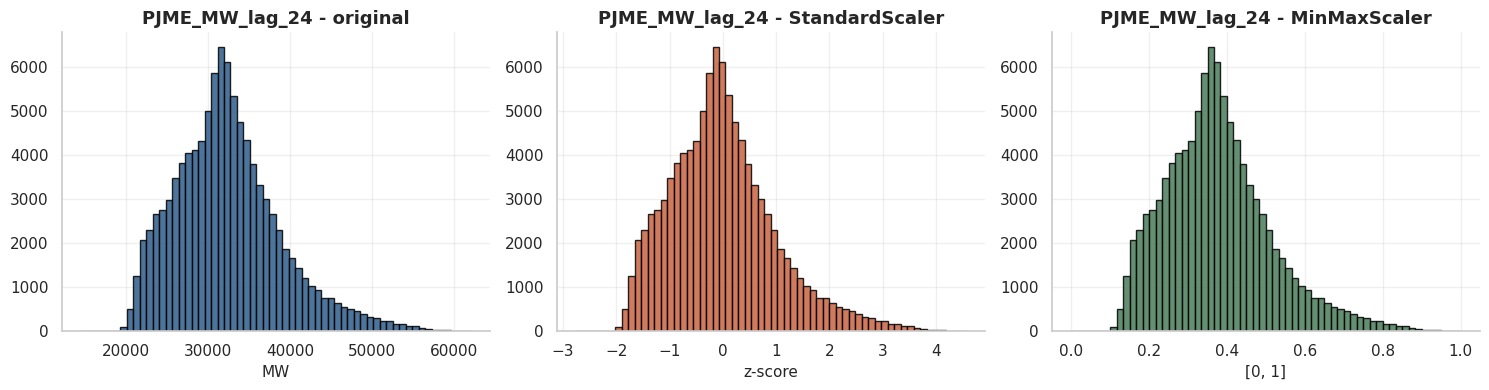

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

target_col = "PJME_MW_lag_24"  # un feature cu scale mare
axes[0].hist(sp["X_train"][target_col], bins=60, color=PALETA["primary"], edgecolor="black", alpha=0.85)
axes[0].set_title(f"{target_col} - original")
axes[0].set_xlabel("MW")
axes[0].grid(True, alpha=0.3)

axes[1].hist(Xt_std[target_col], bins=60, color=PALETA["secondary"], edgecolor="black", alpha=0.85)
axes[1].set_title(f"{target_col} - StandardScaler")
axes[1].set_xlabel("z-score")
axes[1].grid(True, alpha=0.3)

axes[2].hist(Xt_mm[target_col], bins=60, color=PALETA["tertiary"], edgecolor="black", alpha=0.85)
axes[2].set_title(f"{target_col} - MinMaxScaler")
axes[2].set_xlabel("[0, 1]")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretare:** **forma distributiei e identica** in toate cele 3 cazuri (asa trebuie - scalarea e doar o re-scalare liniara). Doar **scala axei X** difera. Asta inseamna ca modelele care se bazeaza pe distante (LSTM, k-NN, SVM) vor primi acum features comparable intre ele.

### 6.3. Verificare anti-leakage

In [16]:
# Test mean si std pe train, val, test
print("StandardScaler aplicat:")
print(f"  Train: mean(prima coloana)={Xt_std.iloc[:, 0].mean():.4f}, std={Xt_std.iloc[:, 0].std():.4f}  (asteptat ~0, ~1)")
print(f"  Val:   mean={Xv_std.iloc[:, 0].mean():.4f}, std={Xv_std.iloc[:, 0].std():.4f}  (poate diferi - normal)")
print(f"  Test:  mean={Xs_std.iloc[:, 0].mean():.4f}, std={Xs_std.iloc[:, 0].std():.4f}  (poate diferi - normal)")

StandardScaler aplicat:
  Train: mean(prima coloana)=0.0000, std=1.0000  (asteptat ~0, ~1)
  Val:   mean=0.0002, std=1.0002  (poate diferi - normal)
  Test:  mean=-0.0002, std=1.0001  (poate diferi - normal)


**Interpretare:** train-ul e perfect normalizat (mean=0, std=1), iar val/test au valori usor diferite. **Asta e corect**, nu o eroare. Daca val/test ar avea exact mean=0 si std=1, ar insemna ca scaler-ul a vazut acele date la fit (leakage). Faptul ca difera demonstreaza ca modelul va fi testat pe distributii reale, nu pe ceva "calibrat" artificial.

## 7. Salvare DataFrame-uri finale v2

Suprascriem fisierele parquet din `data/processed/` cu versiuni care includ noile features (season, virtual_year, performance_ratio etc.). Asa, notebook-urile de ML (05+) vor folosi direct setul complet.

In [17]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

df_usa_v2 = build_features_consum_usa(config=cfg)
df_es_v2 = build_features_pret_spania(config=cfg)
df_in_v2 = build_features_solar_india(config=cfg)

df_usa_v2.to_parquet(processed_dir / "consum_usa_features.parquet")
df_es_v2.to_parquet(processed_dir / "pret_spania_features.parquet")
df_in_v2.to_parquet(processed_dir / "solar_india_features.parquet")

print("Salvat:")
for f in sorted(processed_dir.glob("*.parquet")):
    size_kb = f.stat().st_size / 1024
    df_check = pd.read_parquet(f)
    print(f"  {f.name}: {df_check.shape}, {size_kb:.1f} KB")

Salvat:
  consum_usa_features.parquet: (145194, 31), 10627.7 KB
  pret_spania_features.parquet: (34896, 80), 4436.5 KB
  solar_india_features.parquet: (648, 41), 118.8 KB


## 8. Concluzii

**Ce am adaugat in aceasta etapa de armonizare:**

| Feature | Valoare didactica | Valoare pentru ML |
|---|---|---|
| `virtual_hour_of_year`, `virtual_day_of_year` | Permite suprapunerea celor 3 seturi din ani diferiti | Nu se foloseste direct la antrenare; pentru analiza/vizualizari |
| `season` | Categoric, mai usor de citit decat `month` ciclic | Direct utilizabil de RF / XGBoost |
| `performance_ratio` (Yield) | Indicator standard industrie solar | Predictor cheie pentru AC_POWER |
| `dc_ac_ratio`, `temp_excess`, `eff_temp_corrected` | Surprind eficienta invertorului si efectul temperaturii | Predictori adaugati pentru solar |
| `weather_main_*`, `weather_description_*` (one-hot) | Codifica meteo Spania ca features numerice | Predictori pentru pret |
| `is_outlier_*`, `flag_*` | Permit identificarea / filtrarea anomaliilor | Optional pentru curatare suplimentara |
| Scaler (Standard/MinMax) | Aduce features la aceeasi scala | OBLIGATORIU pentru LSTM, util pentru orice model liniar |

**Stadiul Etapei I (Data Engineering): COMPLET.** Toate punctele cerute in plan sunt acoperite:
1. **Analiza Exploratorie** -> notebook-uri 01, 02, 03
2. **Sincronizare Temporala** -> `add_virtual_year_index` + suprapuneri vizuale
3. **Feature Engineering**:
   - Indice eficienta panouri (Yield) -> `add_solar_efficiency_features`
   - Variabile time-based -> `add_temporal_features`, `add_season`
   - Normalizare pentru DL -> `scale_features`

**Pas urmator:** Etapa II - Modelare ML predictiva (notebook-uri 05, 06, 07 pentru consum, pret, solar).